# Predictive Maintenance Using Machine Learning

## Project Overview
This project focuses on building a machine learning based predictive maintenance system to identify potential equipment failures before they occur.  
The goal is to analyze historical operational data, perform structured exploratory data analysis (EDA), handle class imbalance, and train robust machine learning models to predict failure events effectivAddress class imbalance using appropriate resampling techniques  ely.

## Motivation
Traditional maintenance strategies often lead to unnecessary downtime or unexpected failures. Predictive maintenance enables data driven decision making by detecting early warning signs of failure, improving reliability, reducing costs, and optimizing maintenance schedules.

## Objectives
- Perform meaningful exploratory data analysis (EDA) to guide modeling decisions  
- Address class imbalance using appropriate resampling techniques  
- Train and evaluate traditional machine learning models (non deep learning)  
- Optimize performance using suitable metrics for imbalanced classification  
- Provide interpretable insights that support maintenance decision making


## Dataset Description
This project uses the **AI4I 2020 Predictive Maintenance Dataset** from the UCI Machine Learning Repository.  
It is a synthetic dataset designed to closely reflect real world industrial predictive maintenance scenarios, where real data is often difficult to obtain due to confidentiality and safety concerns.

The dataset contains **10,000 instances** with **multivariate operational measurements** collected from industrial machines.  
Each data point represents a single production process with associated sensor readings and a failure label.

### Key Characteristics
- **Type:** Multivariate, time series inspired (row wise operational snapshots)
- **Task:** Binary classification (machine failure vs normal operation)
- **Target Variable:** `Machine failure` (0 = No failure, 1 = Failure)
- **Missing Values:** None
- **License:** CC BY 4.0 (safe for academic and portfolio use)

### Features Overview
The dataset includes a mix of categorical and numerical features describing machine conditions:

- Product and machine identifiers (`UID`, `Product ID`, `Type`)
- Thermal conditions (`Air temperature`, `Process temperature`)
- Mechanical behavior (`Rotational speed`, `Torque`)
- Tool condition (`Tool wear`)

### Failure Definition
A machine failure occurs when **at least one** of several independent failure modes is triggered, including  
tool wear failure, heat dissipation failure, power failure, overstrain failure, or random failure.

Importantly, the dataset provides **only the final failure label**, making the problem realistic and non trivial, as the specific failure cause is not directly observable by the model.
y observable by the model.y observable by the model.


## Importing libraries

In [6]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import RobustScaler,MinMaxScaler,OrdinalEncoder
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,cross_val_score,cross_val_predict,StratifiedShuffleSplit
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from imblearn.ensemble import BalancedBaggingClassifier,BalancedRandomForestClassifier,EasyEnsembleClassifier,RUSBoostClassifier
from imblearn.under_sampling import RandomUnderSampler,TomekLinks,NearMiss,ClusterCentroids
from imblearn.over_sampling import SMOTE,SVMSMOTE,BorderlineSMOTE,KMeansSMOTE,RandomOverSampler,ADASYN
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score,accuracy_score,classification_report,precision_score,f1_score,recall_score
from sklearn.metrics import confusion_matrix,precision_recall_fscore_support,roc_curve,precision_recall_curve
import pickle
sns.set()


## Loading the dataset and first observations

In [7]:
raw_data = pd.read_csv(r"C:\Users\Ewis\Downloads\ai4i+2020+predictive+maintenance+dataset\ai4i2020.csv")

In [50]:
df = raw_data.copy()
df.sample(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
53,54,L47233,L,298.7,309.0,1565,35.1,152,0,0,0,0,0,0
635,636,L47815,L,298.3,310.0,1858,23.9,114,0,0,0,0,0,0
7187,7188,L54367,L,300.4,310.5,1402,54.3,44,0,0,0,0,0,0
5789,5790,M20649,M,301.8,311.5,1416,49.0,136,0,0,0,0,0,0
7676,7677,L54856,L,300.6,311.7,1448,49.1,206,0,0,0,0,0,0
3550,3551,M18410,M,301.9,311.0,1432,41.5,51,0,0,0,0,0,0
4233,4234,M19093,M,302.2,310.9,1302,53.4,58,0,0,0,0,0,0
836,837,L48016,L,296.6,307.4,1368,45.1,185,0,0,0,0,0,0
7910,7911,M22770,M,300.8,312.2,1664,25.7,150,0,0,0,0,0,0
3253,3254,L50433,L,301.1,309.6,1502,48.9,160,0,0,0,0,0,0


In [51]:
print(f'No of rows:{df.shape[0]} \nNo of  columns:{df.shape[1]}')

No of rows:10000 
No of  columns:14


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [53]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [54]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

## Quick Insights

The dataset contains **10,000 rows** and **no missing values**, making it clean and ready for analysis.

The target variable is **Machine Failure**, which is binary  
`1` represents machine failure  
`0` represents no machine failure

An initial inspection shows that the target variable is **highly imbalanced**, with failure cases being much less frequent than non failure cases. This issue will be addressed later using appropriate imbalance handling techniques.

The columns **TWF, HDF, PWF, OSF, and RNF** appear to represent different failure types. Since the main objective is to predict overall machine failure, these columns are not required for this analysis.

The **UDI** column acts as an index and **ProductID** is an identification variable. Both do not provide predictive value and are therefore excluded from the modeling process.


In [59]:
print(f'Unique values for UDI:{df["UDI"].nunique()}')
print(f'Unique values for Product ID:{df["Product ID"].nunique()}')

Unique values for UDI:10000
Unique values for Product ID:10000


Dropping UDI,Product ID,TWF, HDF, PWF, OSF, and RNF from the dataset

In [62]:
df.drop(['UDI','Product ID','TWF','HDF','PWF','OSF','RNF'], axis=1, inplace=True)

In [64]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


Rename columns for cleaner and more manageable feature names

In [68]:
df.rename(mapper={'Air temperature [K]':'Air temperature',
                  'Process temperature [K]':'Process temperature',
                   'Rotational speed [rpm]':'Rotational speed',
                   'Torque [Nm]':'Torque',
                   'Tool wear [min]':'Tool wear'} , axis=1, inplace=True)

In [71]:
df.columns

Index(['Type', 'Air temperature', 'Process temperature', 'Rotational speed',
       'Torque', 'Tool wear', 'Machine failure'],
      dtype='object')

Take a look at the target variable

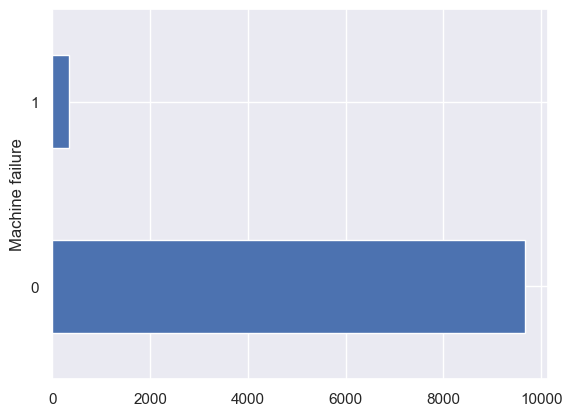

In [81]:
df['Machine failure'].value_counts().plot(kind='barh')
plt.show()

The dataset is highly imbalanced. We will handle this later

Inspect the data types of all columns

In [85]:
df.dtypes

Type                    object
Air temperature        float64
Process temperature    float64
Rotational speed         int64
Torque                 float64
Tool wear                int64
Machine failure          int64
dtype: object

In [88]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

## Column Data Types

- **Type:** object  
- **Air temperature:** float64  
- **Process temperature:** float64  
- **Rotational speed:** int64  
- **Torque:** float64  
- **Tool wear:** int64  
- **Machine failure:** int64

> All columns except `Type` are numeric and ready for analysis. The `Type` column is categorical and may require encoding


## Explanatory Data Analysis (EDA)

## Correlation

<Figure size 1400x1000 with 0 Axes>

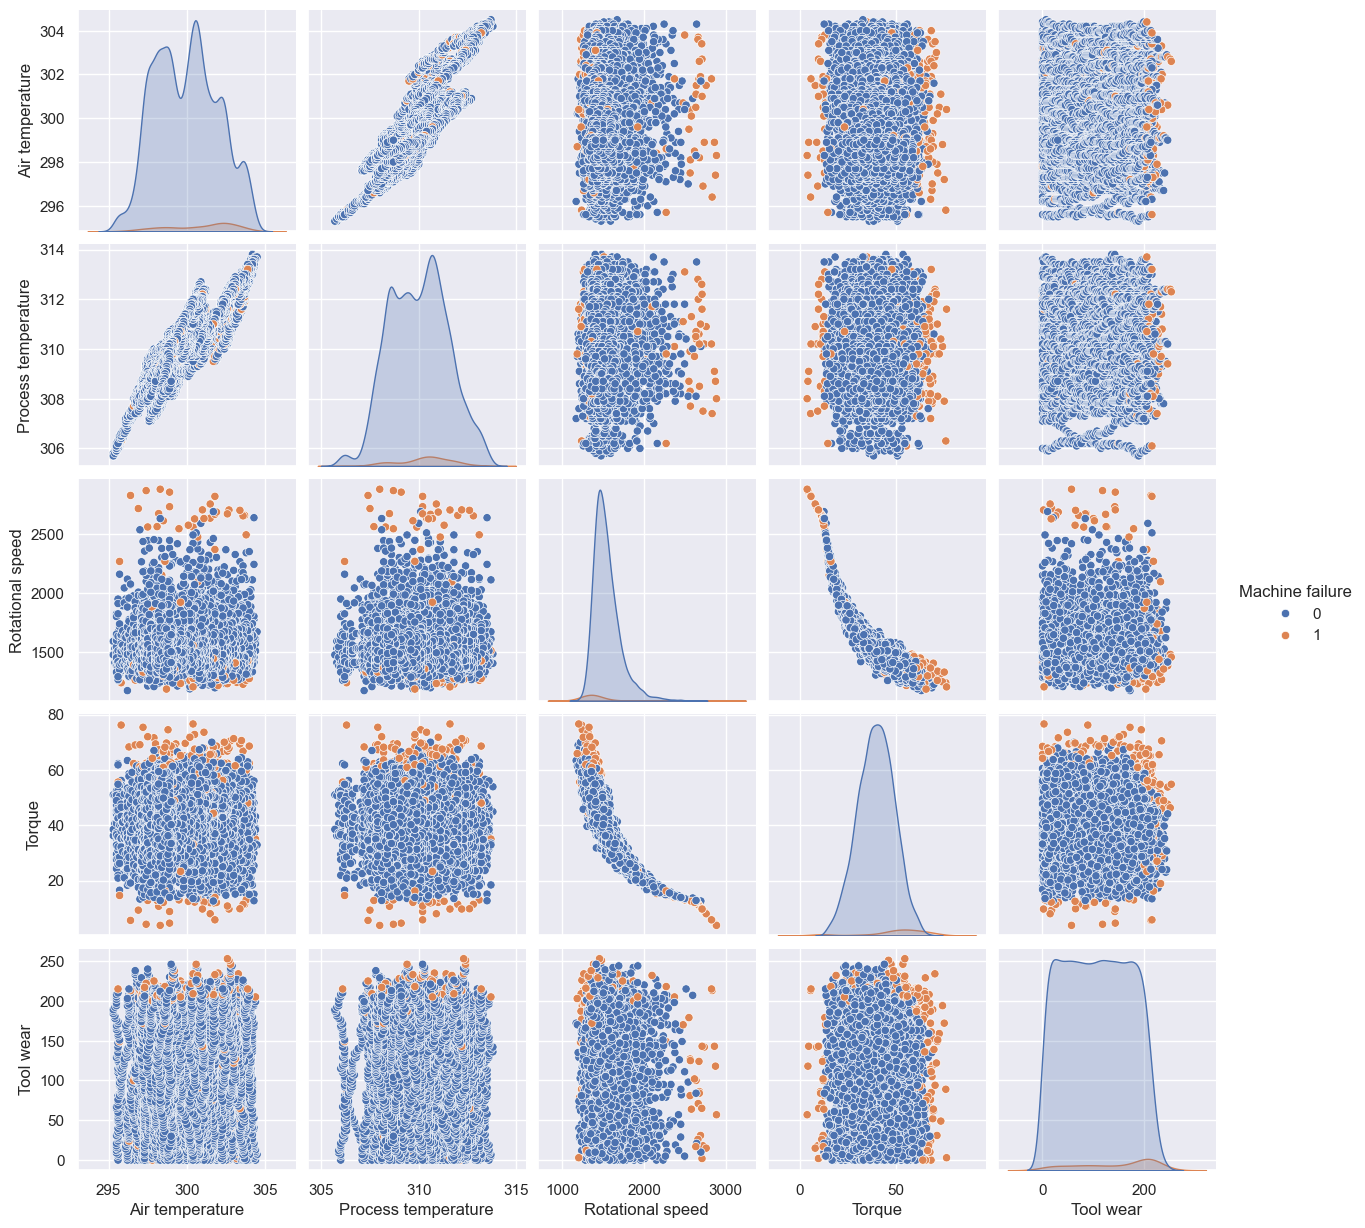

In [92]:
plt.figure(figsize=(14,10))
sns.pairplot(data=df, hue='Machine failure')
plt.show()

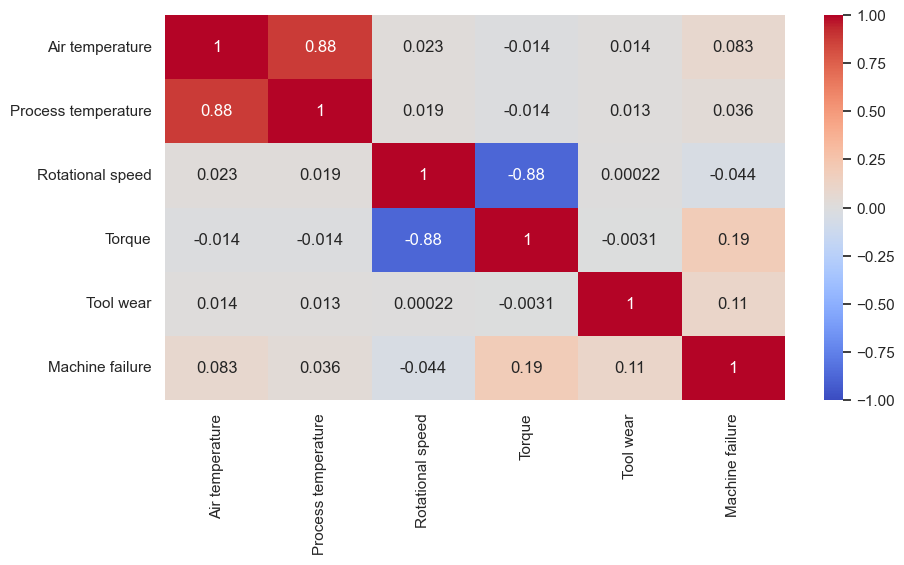

In [120]:
df_cor = df[['Air temperature', 'Process temperature', 'Rotational speed',
       'Torque', 'Tool wear', 'Machine failure']].corr(method='pearson')

sns.set_theme(palette='pastel')
plt.figure(figsize=(10,5))
sns.heatmap(data=df_cor, vmax=1, vmin=-1, annot=True, cbar=True,  cmap='coolwarm')
plt.show()


## Correlation Insights

Looking at the correlation matrix, a few things stand out:

- **Air temperature** and **Process temperature** are highly correlated (~0.88). This makes sense since they likely change together during machine operation.  
- **Rotational speed** and **Torque** have a strong negative correlation (~-0.88). So as the machine spins faster, the torque tends to decrease.  
- **Machine failure** has the highest correlation with **Torque** (~0.19) and **Tool wear** (~0.11), which suggests these features might be more important for predicting failures.  
- Other features like **Air temperature**, **Process temperature**, and **Rotational speed** have very low correlation with the target, meaning their direct impact on machine failure might be small.  
- Overall, there are no extremely high correlations with the target, so we might need **more advanced techniques** (like feature engineering or ML models) to capture failure patterns.


## Feature Behavior and Failures

We can immediately see that machine failures tend to occur at **extreme values** of certain features.  
For example, machinery fails when **Torque** or **Rotational Speed** are either very low or very high.  

In the graph, this is noticeable because the orange dots (failures) are far apart for these features.  
This suggests that there is a **normal operating range** for the machines, and outside this range, failures are more likely.

Next, let's plot a **violin chart** to visualize how Torque and Rotational Speed behave across normal and failure cases.


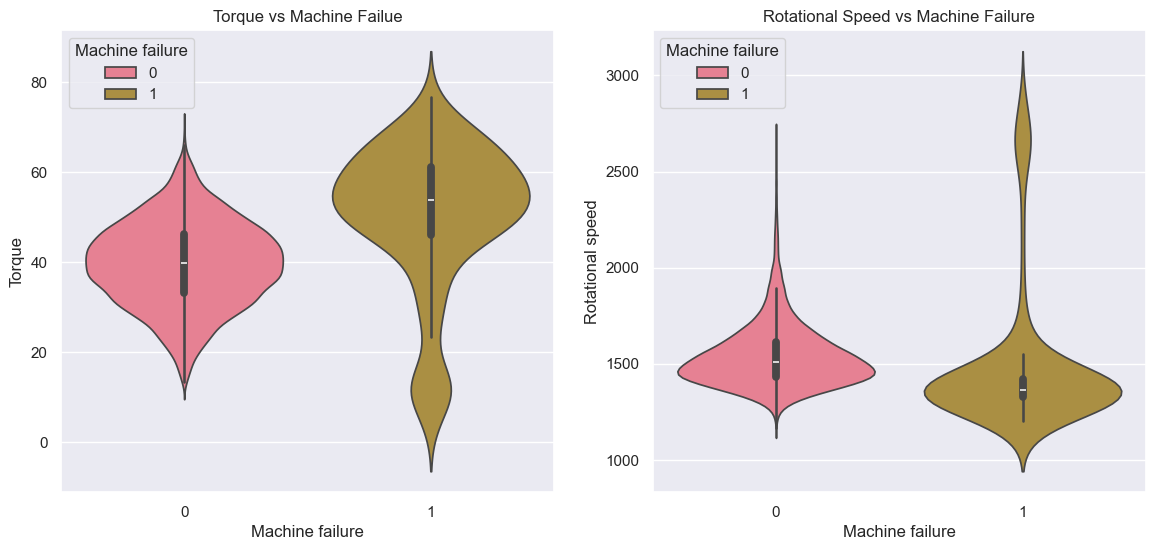

In [142]:
df_violin1 = df[['Torque','Machine failure']]  
df_violin2 = df[['Rotational speed','Machine failure']]  

fig, axes =  plt.subplots(1,2, figsize=(14,6))
sns.set_theme(palette='husl')

sns.violinplot(data=df_violin1, x='Machine failure', y='Torque', hue='Machine failure', ax=axes[0])
axes[0].set_title('Torque vs Machine Failue')

sns.violinplot(data=df_violin2, x='Machine failure', y='Rotational speed', hue='Machine failure', ax=axes[1])
axes[1].set_title('Rotational Speed vs Machine Failure')

plt.show()

## Percentage of failure

In [144]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

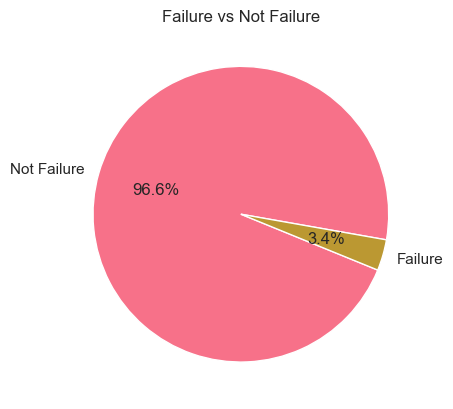

In [163]:
fig, axes = plt.subplots()
axes.set_title('Failure vs Not Failure')
axes.pie(df['Machine failure'].value_counts(), autopct='%1.1f%%', labels=['Not Failure','Failure'], startangle=350)
plt.show()

Insight: as mentioned before, highly unbalanced dataset

## Product types

In [168]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

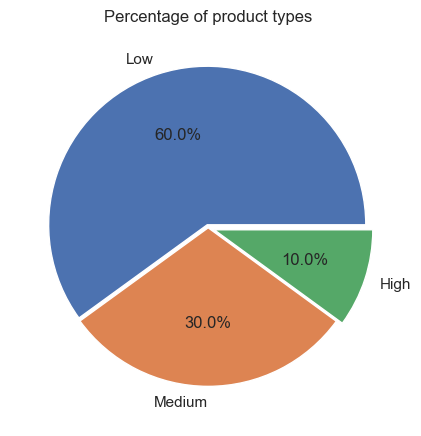

In [397]:
fig, axes = plt.subplots()

axes.set_title('Percentage of product types')
plt.tight_layout()
axes.pie(df['Type'].value_counts(),autopct='%1.1f%%',labels=['Low','Medium','High'],explode=[0.02, 0, 0.04])
plt.show()

## Percentage of failure with respect to product type

In [206]:
df.groupby('Type')['Machine failure'].value_counts()

Type  Machine failure
H     0                   982
      1                    21
L     0                  5765
      1                   235
M     0                  2914
      1                    83
Name: count, dtype: int64

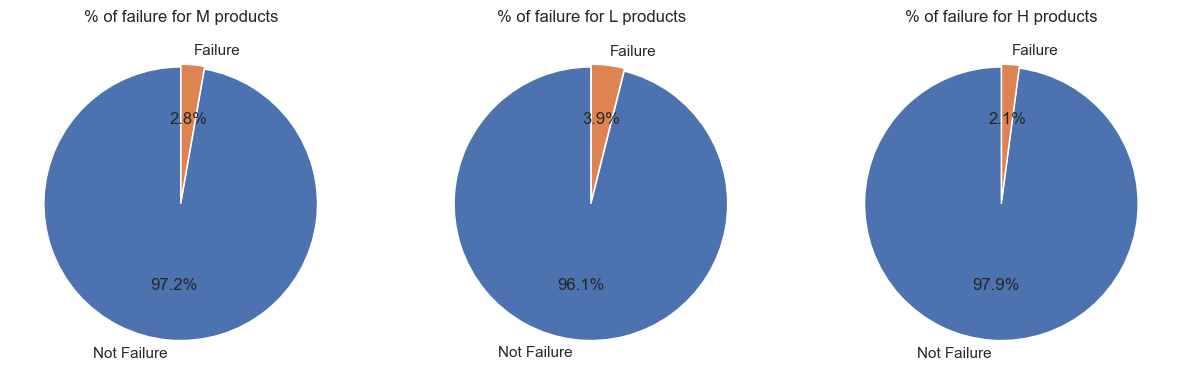

In [244]:
fig, axes = plt.subplots(1,3, figsize=[15,5])
j = 0

for i in ['M','L','H']:

    data = df[['Type','Machine failure']][df['Type'] == i].value_counts()

    axes[j].pie(data,
            labels = ['Not Failure','Failure'],
            autopct = '%1.1f%%',
            startangle = 90,
            explode = [0.02,0],
           )
    axes[j].set_title(f'% of failure for {i} products')
    j = j + 1


When we break down machine failures by product type, a clear pattern appears.

- **L type products** have the highest number of failures (235), which is expected since they also have the largest number of total samples.
- **M type products** show fewer failures (83) compared to L type, even with a reasonably large sample size.
- **H type products** have the lowest number of failures (21), suggesting better overall reliability.

Although failures are relatively rare across all product types, the failure rate is **not uniform**.  
This indicates that **product type is an important feature** and may influence machine reliability, making it worth keeping for modeling and further analysis.


## Distribution

In [245]:
df.columns

Index(['Type', 'Air temperature', 'Process temperature', 'Rotational speed',
       'Torque', 'Tool wear', 'Machine failure'],
      dtype='object')

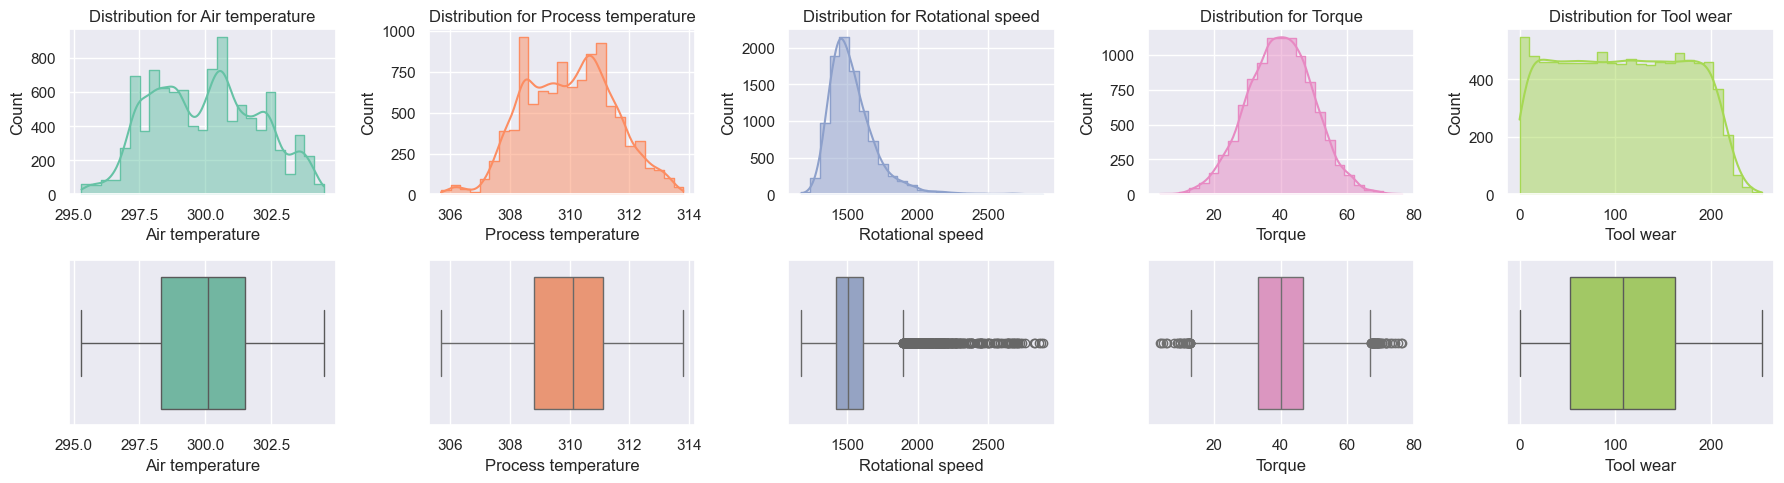

In [296]:
labels  =  ['Air temperature', 'Process temperature', 'Rotational speed','Torque', 'Tool wear']

fig, axes =  plt.subplots(2,5, figsize=(18,5))

colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']

j = 0

for i in labels:

    data = df[i]
    sns.histplot(data, bins=25, element='step',  kde=True, ax=axes[0,j],color=colors[j],)
    sns.boxplot(data, orient='h', ax=axes[1,j],color=colors[j],)

    axes[0,j].set_title(f'Distribution for {i}')

    j =  j  +1
    
plt.tight_layout()
plt.show()    

In [305]:
print('----Skewness----\n')
print(round(df[labels].skew(),2))

----Skewness----

Air temperature        0.11
Process temperature    0.02
Rotational speed       1.99
Torque                -0.01
Tool wear              0.03
dtype: float64


Except for rotational speed, all features show near symmetric distributions. Rotational speed stands out with a clear right skew and may require special attention during modeling

From the boxplots we can see that 'Rotational speed' and 'Torque' have outliers.
Let's check those potential 'outliers' by analyzing the boxplots:

In [360]:
def outlier_detection(data_column):
    max = df[data_column].max()
    min = df[data_column].min()

    q1 = df[data_column].quantile(0.25)
    q3 = df[data_column].quantile(0.75)

    iqr =  q3 - q1

    upper_boundry =  q3 + 1.5 * iqr
    lower_boundry = q1 - 1.5 * iqr

    return upper_boundry,lower_boundry

#for rotational speed

print('=== For rotational speed ==\n')

print(f'upper boundry : {ub1}')
print(f'lower boundry : {lb1}')

ub1, lb1 = outlier_detection('Rotational speed')
count1 = df[(df['Rotational speed']> ub1) | (df['Rotational speed'] < lb1)]['Type'].count()
print(f'No of outliers Rotational speed feature has: {count1}\n')

#for torque

print('=== For torque ==\n')

print(f'upper boundry : {round(ub2,2)}')
print(f'lower boundry : {round(lb2,2)}')
    
ub2, lb2 = outlier_detection('Torque')
count2 = df[(df['Torque']> ub2) | (df['Torque'] < lb2)]['Type'].count()
print(f'No of outliers Torque feature has: {count2}')
  

=== For rotational speed ==

upper boundry : 1895.5
lower boundry : 1139.5
No of outliers Rotational speed feature has: 418

=== For torque ==

upper boundry : 67.2
lower boundry : 12.8
No of outliers Torque feature has: 69



Total dataset size is 10,000. Rotational speed has a high number of outliers. The box plot shows most outliers on the right side, meaning very high rotational speeds are common. Torque has far fewer outliers and looks fairly well distributed on both sides in the box plot.

let's anyalize thease outliers with respect to types - [Low,Medium,High]

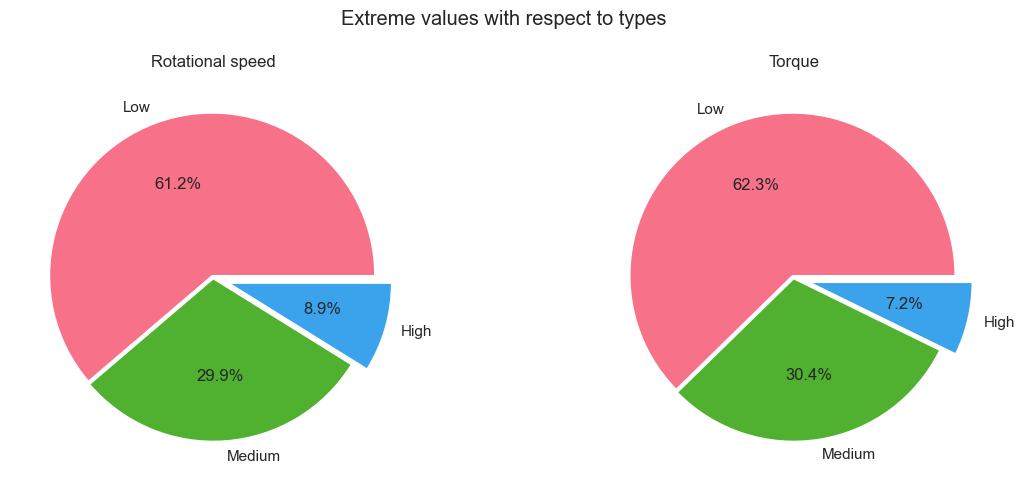

In [396]:
data1 =  df[(df['Rotational speed']> ub1) | (df['Rotational speed'] < lb1)]['Type'].value_counts()
data2 =  df[(df['Torque']> ub2) | (df['Torque'] < lb2)]['Type'].value_counts()

colors = sns.color_palette('husl', n_colors=3)

fig, axes =  plt.subplots(1,2, figsize=(12,5))
fig.suptitle('Extreme values with respect to types')
axes[0].set_title('Rotational speed')
axes[0].pie(data1, labels=['Low','Medium','High'], autopct='%1.1f%%', explode=[0.02,0.0,0.1], colors=colors)

axes[1].set_title('Torque')
axes[1].pie(data2, labels=['Low','Medium','High'], autopct='%1.1f%%', explode=[0.02,0.0,0.1], colors=colors)

fig.tight_layout()
plt.show()

For rotational speed, most extreme values belong to Low (L) type machines, followed by Medium (M), while High (H) type machines contribute the least.

A similar pattern appears for torque, where Low (L) type machines again dominate the extreme values.

This suggests that L type machines operate more often at extreme conditions, which may increase their exposure to failures compared to other types.

## Data Preprocessing

## Ordinal Encoding

In [412]:
df['Type'].unique()

array(['M', 'L', 'H'], dtype=object)

In [424]:
sizes = [['L','M','H']]

enc = OrdinalEncoder(categories=sizes)

type_encoded =  enc.fit_transform(df[['Type']])

df['Type'] = type_encoded


In [425]:
df.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure
0,1.0,298.1,308.6,1551,42.8,0,0
1,0.0,298.2,308.7,1408,46.3,3,0
2,0.0,298.1,308.5,1498,49.4,5,0
3,0.0,298.2,308.6,1433,39.5,7,0
4,0.0,298.2,308.7,1408,40.0,9,0


## Scaling  the data

since Rotational speedand Torque has some outliers, robust Scaler will be using

In [8]:
#just accdeintly dropped the data. load again

df = raw_data.copy()
df.drop(['UDI','Product ID','TWF','HDF','PWF','OSF','RNF'], axis=1, inplace=True)
df.rename(mapper={'Air temperature [K]':'Air temperature',
                  'Process temperature [K]':'Process temperature',
                   'Rotational speed [rpm]':'Rotational speed',
                   'Torque [Nm]':'Torque',
                   'Tool wear [min]':'Tool wear'} , axis=1, inplace=True)

sizes = [['L','M','H']]

enc = OrdinalEncoder(categories=sizes)

type_encoded =  enc.fit_transform(df[['Type']])

df['Type'] = type_encoded

In [10]:
transformer = RobustScaler()

columns =  ['Rotational speed','Torque']

scaled = transformer.fit_transform(df[columns])

scaled_df = pd.DataFrame(scaled, columns=columns)

df.drop(columns, axis=1, inplace=True)

df = pd.concat([df,scaled_df], axis=1)


In [11]:
df.head()

,Type,Air temperature,Process temperature,Tool wear,Machine failure,Rotational speed,Torque
0,1.0,298.1,308.6,0,0,0.253968,0.198529
1,0.0,298.2,308.7,3,0,-0.502646,0.455882
2,0.0,298.1,308.5,5,0,-0.026455,0.683824
3,0.0,298.2,308.6,7,0,-0.370370,-0.044118
4,0.0,298.2,308.7,9,0,-0.502646,-0.007353


The rest of the features will be scaled with MinMax scaling

In [12]:
columns =  ['Air temperature','Process temperature','Tool wear']

scaler = MinMaxScaler(feature_range=(0,1))

scaled = scaler.fit_transform(df[columns])

df_scaled = pd.DataFrame(scaled, columns=columns)


In [13]:
df.drop(columns,axis=1, inplace=True)

df = pd.concat([df,df_scaled], axis=1)

In [20]:
df_scaled = df.copy()


## Modeling with 'Target' variable



first let's change 'Machine failure' to 'Target' make it easier to interpret

In [21]:
df_scaled.rename(mapper={'Machine failure':'Target'}, axis=1, inplace=True)

In [22]:
df_scaled.head()

,Type,Target,Rotational speed,Torque,Air temperature,Process temperature,Tool wear
0,1.0,0,0.253968,0.198529,0.304348,0.358025,0.000000
1,0.0,0,-0.502646,0.455882,0.315217,0.370370,0.011858
2,0.0,0,-0.026455,0.683824,0.304348,0.345679,0.019763
3,0.0,0,-0.370370,-0.044118,0.315217,0.358025,0.027668
4,0.0,0,-0.502646,-0.007353,0.315217,0.370370,0.035573


As the dataset is unbalanced, I am going to used macro f1 score and ROC AUC score to assess model performance.

First, let's build a model with 'Target'

## Stratified Split

In [34]:
X = df_scaled.drop(['Target'], axis=1)
y = df['Target']

sss = StratifiedShuffleSplit(n_splits=1, random_state=42,  test_size=0.25)

for train_index, test_index in sss.split(X,y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
  

In [53]:
print('=== original data distribution of the target ===\n')
print(df_scaled['Target'].value_counts(normalize=True) , '\n')

print('=== Training data distribution of the target ===\n')
print(y_train.value_counts(normalize=True))

print('=== Testing data distribution of the target ===\n')
print(y_test.value_counts(normalize=True))

=== original data distribution of the target ===

Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64 

=== Training data distribution of the target ===

Target
0    0.966133
1    0.033867
Name: proportion, dtype: float64
=== Testing data distribution of the target ===

Target
0    0.966
1    0.034
Name: proportion, dtype: float64


The proportions are similar. Therefore, it was correctly splitted

## Balanced Models

Let's train some base models to check how they perform

In [144]:
from sklearn.model_selection import StratifiedKFold, cross_validate

brf = BalancedRandomForestClassifier(
    n_estimators=100,
    random_state=42,
    sampling_strategy='auto',
    replacement=False
)

bbc = BalancedBaggingClassifier(n_estimators=100,
                               random_state=42,
                                sampling_strategy='auto',
                                replacement=False
                               )

rusb = RUSBoostClassifier(n_estimators=100,
                               random_state=42,
                                sampling_strategy='auto',
                                replacement=False
                               )
eec = EasyEnsembleClassifier(n_estimators=100,
                               random_state=42,
                                sampling_strategy='auto',
                                replacement=False
                               )

models = [brf, bbc, rusb, eec]
names= ['BalancedRandomForestClassifier','BalancedBaggingClassifier','RUSBoostClassifier','EasyEnsembleClassifier']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["f1_macro", "precision_macro", "recall_macro"]

for model,name in zip(models,names):
    
    scores = cross_validate(model, X, y, cv=skf, scoring=scoring)

    print(f'== Fitting {name} n_estimators=100 ==\n')

    print("F1 Macro per fold:", scores['test_f1_macro'])
    print("Precision Macro per fold:", scores['test_precision_macro'])
    print("Recall Macro per fold:", scores['test_recall_macro'])

    print("\nAverage F1 Macro:", round(scores['test_f1_macro'].mean(),2))
    print("Average Precision Macro:", round(scores['test_precision_macro'].mean(),2))
    print("Average Recall Macro:", round(scores['test_recall_macro'].mean(),2))

    print()

== Fitting BalancedRandomForestClassifier n_estimators=100 ==

F1 Macro per fold: [0.65423146 0.66462281 0.65264974 0.64767236 0.67046406]
Precision Macro per fold: [0.613452   0.61995129 0.61226745 0.60966497 0.62365851]
Recall Macro per fold: [0.92816826 0.92514615 0.90785227 0.91867617 0.92721654]

Average F1 Macro: 0.66
Average Precision Macro: 0.62
Average Recall Macro: 0.92

== Fitting BalancedBaggingClassifier n_estimators=100 ==

F1 Macro per fold: [0.69885677 0.69692888 0.69885677 0.68365871 0.7120361 ]
Precision Macro per fold: [0.64265364 0.64177732 0.64301928 0.63234251 0.65301978]
Recall Macro per fold: [0.93648416 0.92260382 0.92969797 0.93161612 0.92674461]

Average F1 Macro: 0.7
Average Precision Macro: 0.64
Average Recall Macro: 0.93

== Fitting RUSBoostClassifier n_estimators=100 ==

F1 Macro per fold: [0.67173651 0.65943407 0.51087326 0.65016895 0.68281347]
Precision Macro per fold: [0.65452311 0.63620689 0.52792807 0.65722894 0.65293379]
Recall Macro per fold: [0.69

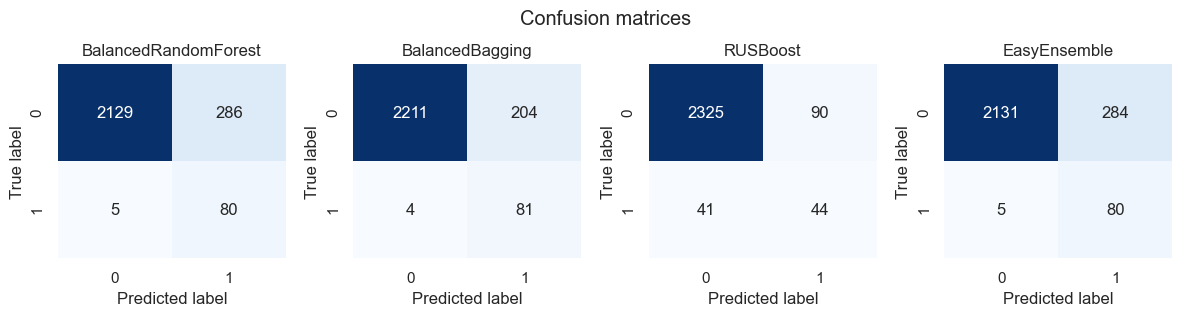

In [148]:
brf.fit(X_train, y_train)
y_pred1 =  brf.predict(X_test)

bbc.fit(X_train, y_train)
y_pred2 =  bbc.predict(X_test)

rusb.fit(X_train, y_train)
y_pred3 =  rusb.predict(X_test)

eec.fit(X_train, y_train)
y_pred4 =  eec.predict(X_test)

cm1 = confusion_matrix(y_test,y_pred1)
cm2 = confusion_matrix(y_test,y_pred2)
cm3 = confusion_matrix(y_test,y_pred3)
cm4 = confusion_matrix(y_test,y_pred4)

fig, axes = plt.subplots(1,4, figsize=(12,3))

fig.suptitle('Confusion matrices')
plt.tight_layout()
sns.set_theme(palette='pastel')

sns.heatmap(data=cm1, annot=True, fmt='d', cbar=False, ax=axes[0], cmap='Blues')
axes[0].set_title('BalancedRandomForest')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

sns.heatmap(data=cm2, annot=True, fmt='d', cbar=False, ax=axes[1],cmap='Blues')
axes[1].set_title('BalancedBagging')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

sns.heatmap(data=cm3, annot=True, fmt='d', cbar=False, ax=axes[2],cmap='Blues')
axes[2].set_title('RUSBoost')
axes[2].set_xlabel('Predicted label')
axes[2].set_ylabel('True label')

sns.heatmap(data=cm4, annot=True, fmt='d', cbar=False, ax=axes[3],cmap='Blues')
axes[3].set_title('EasyEnsemble')
axes[3].set_xlabel('Predicted label')
axes[3].set_ylabel('True label')

plt.show()


~

All results are using 5 fold cross validation:

- **Balanced Bagging**: Best overall model with **highest F1 Macro (0.70)** and **highest recall (0.93)**, showing strong balance between precision and recall.
- **Balanced Random Forest**: Slightly lower F1 Macro (0.66) but high recall (0.92), effective at capturing positive cases.
- **Easy Ensemble**: Similar recall (0.91) but lower F1 Macro (0.65), indicating more false positives.
- **RUSBoost**: Lowest recall (0.68) and unstable F1 across folds, less reliable on this dataset.


## Oversampling and undersampling with Random Forest and Bagging classifiers

Now, let's try using different sampling techniques with random forest and balanced bagging to see if we achieve better performance than the balanced models:

## RandomForestClassifier

Hyperparameter tuning


In [185]:
rdfo = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 15, 200],
    'min_samples_split': [2, 5, 10]
}

rs = RandomizedSearchCV(
    estimator=rdfo,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

rs.fit(X_train, y_train)

best_params = rs.best_params_
print("Best params:", best_params)

Best params: {'n_estimators': 50, 'min_samples_split': 2, 'max_depth': None}


We use this to Apply sampling

In [189]:
samplers = [
    RandomOverSampler(random_state=42),
    SMOTE(random_state=42),
    BorderlineSMOTE(random_state=42),
    ClusterCentroids(random_state=42),
    TomekLinks(),
    NearMiss(version=3)
]

names = [
    'RandomOverSampler',
    'SMOTE',
    'BorderlineSMOTE',
    'ClusterCentroids',
    'TomekLinks',
    'NearMiss'
]

for sampler, name in zip(samplers, names):

    X_res, y_res = sampler.fit_resample(X_train, y_train)

    model = RandomForestClassifier(
        **best_params,
        random_state=42
    )

    model.fit(X_res, y_res)

    #evaluating
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f'=== Sampling method: {name} ===')
    print('Test F1-macro:', round(f1, 3))
    print()


=== Sampling method: RandomOverSampler ===
Test F1-macro: 0.863

=== Sampling method: SMOTE ===
Test F1-macro: 0.8

=== Sampling method: BorderlineSMOTE ===
Test F1-macro: 0.819



C:\Users\Ewis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


=== Sampling method: ClusterCentroids ===
Test F1-macro: 0.624

=== Sampling method: TomekLinks ===
Test F1-macro: 0.852

=== Sampling method: NearMiss ===
Test F1-macro: 0.686



## Bagging classifier

Hyperparameter tuning

In [192]:
bgcf = BaggingClassifier(random_state=42)

param_dist = {
    'n_estimators': [50, 100, 200, 300],
}

rs = RandomizedSearchCV(
    estimator=bgcf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

rs.fit(X_train, y_train)

best_params = rs.best_params_
print("Best params:", best_params)

C:\Users\Ewis\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params: {'n_estimators': 50}


We use this to Apply sampling

In [193]:
samplers = [
    RandomOverSampler(random_state=42),
    SMOTE(random_state=42),
    BorderlineSMOTE(random_state=42),
    ClusterCentroids(random_state=42),
    TomekLinks(),
    NearMiss(version=3)
]

names = [
    'RandomOverSampler',
    'SMOTE',
    'BorderlineSMOTE',
    'ClusterCentroids',
    'TomekLinks',
    'NearMiss'
]

for sampler, name in zip(samplers, names):

    X_res, y_res = sampler.fit_resample(X_train, y_train)

    model = BaggingClassifier(
        **best_params,
        random_state=42
    )

    model.fit(X_res, y_res)

    #evaluating
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f'=== Sampling method: {name} ===')
    print('Test F1-macro:', round(f1, 3))
    print()


=== Sampling method: RandomOverSampler ===
Test F1-macro: 0.834

=== Sampling method: SMOTE ===
Test F1-macro: 0.781

=== Sampling method: BorderlineSMOTE ===
Test F1-macro: 0.825



C:\Users\Ewis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


=== Sampling method: ClusterCentroids ===
Test F1-macro: 0.644

=== Sampling method: TomekLinks ===
Test F1-macro: 0.881

=== Sampling method: NearMiss ===
Test F1-macro: 0.673



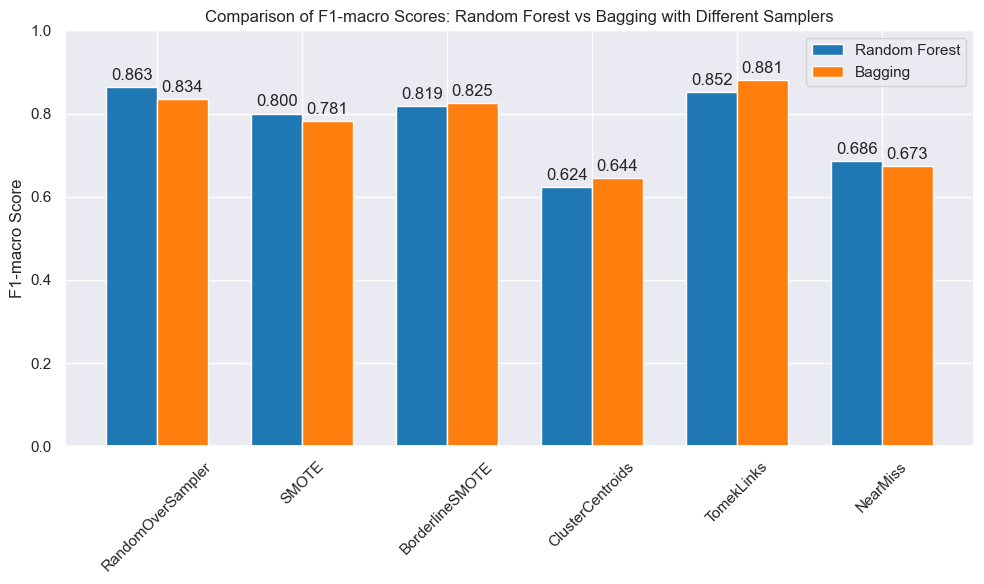

In [208]:
samplers = ['RandomOverSampler', 'SMOTE', 'BorderlineSMOTE', 'ClusterCentroids', 'TomekLinks', 'NearMiss']

rf_scores = [0.863, 0.800, 0.819, 0.624, 0.852, 0.686]
bagging_scores = [0.834, 0.781, 0.825, 0.644, 0.881, 0.673]

x = np.arange(len(samplers))
width = 0.35  

fig, ax = plt.subplots(figsize=(10,6))

rects1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest', color='#1f77b4')
rects2 = ax.bar(x + width/2, bagging_scores, width, label='Bagging', color='#ff7f0e')

ax.set_ylabel('F1-macro Score')
ax.set_title('Comparison of F1-macro Scores: Random Forest vs Bagging with Different Samplers')
ax.set_xticks(x)
ax.set_xticklabels(samplers, rotation=45)
ax.set_ylim(0, 1)
ax.legend()

for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()


Overall, the models show interesting differences in performance across sampling techniques.  

- **Random Forest** achieved the highest F1-macro score with **RandomOverSampler**, while **TomekLinks** also performed well.  
- **BaggingClassifier** reached its highest F1-macro score with **TomekLinks**, showing that noise removal benefits Bagging more than simple oversampling.  
- Undersampling techniques like **NearMiss** and **ClusterCentroids** led to significantly lower F1 scores for both models, indicating that aggressive removal of majority samples hurts tree based models.  
- SMOTE based methods (**SMOTE**, **BorderlineSMOTE**) provided moderate improvements but were not as effective as RandomOverSampler or TomekLinks for these models.  

**Key takeaway:**  
- Bagging + TomekLinks and Random Forest + RandomOverSampler are the **best performing combinations**.  
- Macro F1 scores improve dramatically when using these sampling techniques, making these models potentially better than the baseline balanced ones.  
- In my opinion, Random Forest with BorderlineSMOTE offers a reasonable balance, but the absolute highest F1 score comes from **Bagging + TomekLinks**.  

From now on, I will continue focusing on these two models and the balanced Bagging one, comparing their performance across different sampling strategies


## Train chosen models

